In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')
customer_summary = pd.read_csv(
    '../data/processed/customer_summary.csv')

print(" All ML libraries loaded!")
print("Customer data loaded!")
print("Shape:", customer_summary.shape)

 All ML libraries loaded!
Customer data loaded!
Shape: (495, 10)


In [3]:
features = ['total_transactions', 'total_spend', 
            'avg_spend', 'unique_locations',
            'unique_devices', 'InactiveDays']

X = customer_summary[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_summary['Cluster'] = kmeans.fit_predict(X_scaled)

# Label the clusters
cluster_labels = {
    0: 'Champions',
    1: 'At-Risk',
    2: 'Dormant',
    3: 'Promising'
}
customer_summary['Segment'] = customer_summary['Cluster'].map(cluster_labels)

print("✅ K-Means Clustering Done!")
print("\nCustomer Segments:")
print(customer_summary['Segment'].value_counts())

✅ K-Means Clustering Done!

Customer Segments:
Segment
Dormant      190
At-Risk      132
Champions     97
Promising     76
Name: count, dtype: int64


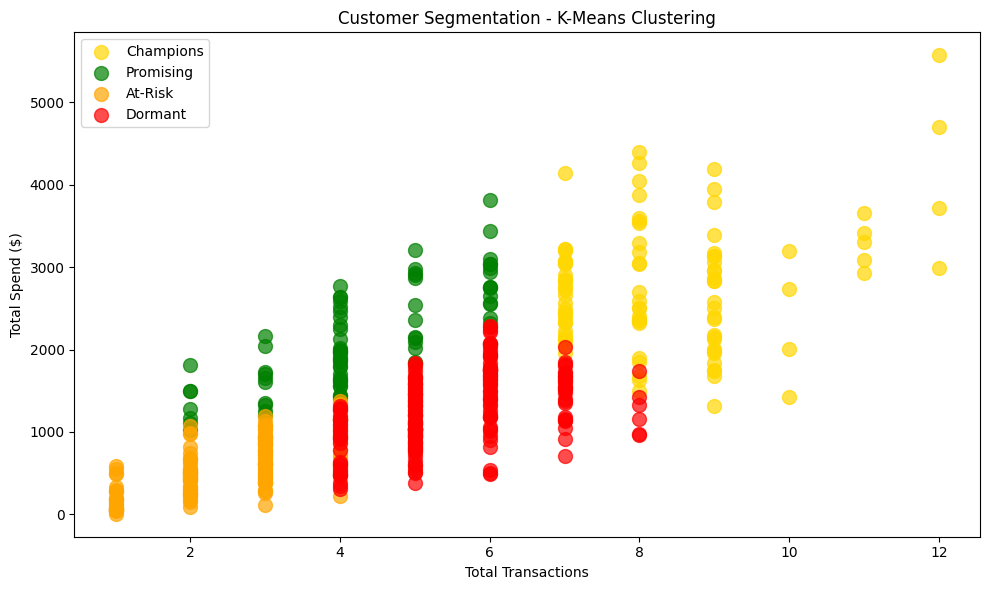

 Chart saved!


In [4]:
plt.figure(figsize=(10, 6))
colors = {'Champions': 'gold', 'Promising': 'green', 
          'At-Risk': 'orange', 'Dormant': 'red'}

for segment, color in colors.items():
    mask = customer_summary['Segment'] == segment
    plt.scatter(
        customer_summary[mask]['total_transactions'],
        customer_summary[mask]['total_spend'],
        c=color, label=segment, s=100, alpha=0.7
    )

plt.xlabel('Total Transactions')
plt.ylabel('Total Spend ($)')
plt.title('Customer Segmentation - K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/customer_segments.png')
plt.show()
print(" Chart saved!")

In [5]:
churn = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
features = ['CreditScore', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 
            'IsActiveMember', 'EstimatedSalary']

X = churn[features]
y = churn['Exited'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(" Random Forest Churn Model Done!")
print("\n Model Performance:")
print(classification_report(y_test, y_pred))

 Random Forest Churn Model Done!

 Model Performance:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1607
           1       0.72      0.42      0.53       393

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.84      0.85      0.84      2000



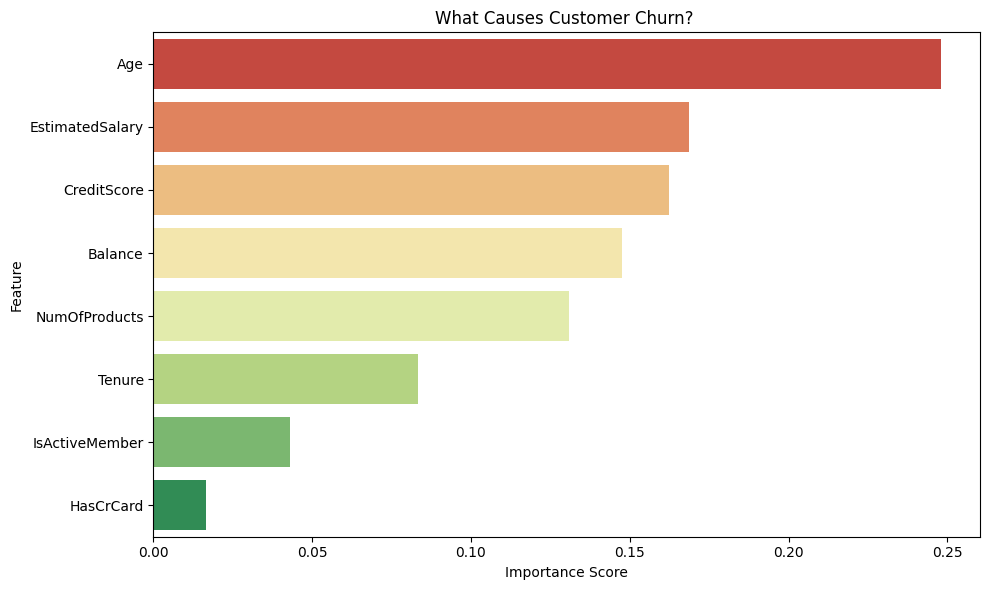

 Feature importance chart saved!
           Feature  Importance
1              Age    0.247877
7  EstimatedSalary    0.168487
0      CreditScore    0.162439
3          Balance    0.147624
4    NumOfProducts    0.130732
2           Tenure    0.083469
6   IsActiveMember    0.042921
5        HasCrCard    0.016452


In [6]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, 
            x='Importance', y='Feature', 
            palette='RdYlGn')
plt.title('What Causes Customer Churn? ')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../docs/churn_factors.png')
plt.show()

print(" Feature importance chart saved!")
print(feature_importance)

In [7]:
from sklearn.ensemble import IsolationForest

fraud_features = ['total_transactions', 'total_spend',
                  'unique_devices', 'unique_locations',
                  'avg_spend', 'InactiveDays']

X_fraud = customer_summary[fraud_features].fillna(0)

iso_forest = IsolationForest(
    contamination=0.05, random_state=42)
customer_summary['fraud_score'] = iso_forest.fit_predict(X_fraud)

customer_summary['fraud_risk'] = customer_summary[
    'fraud_score'].map({1: 'Normal', -1: 'Suspicious'})

print("✅ Fraud Detection Done!")
print("\nFraud Risk Summary:")
print(customer_summary['fraud_risk'].value_counts())

✅ Fraud Detection Done!

Fraud Risk Summary:
fraud_risk
Normal        470
Suspicious     25
Name: count, dtype: int64


In [8]:
import joblib

joblib.dump(rf_model, '../models/churn_model.pkl')
joblib.dump(iso_forest, '../models/fraud_model.pkl')
joblib.dump(kmeans, '../models/clustering_model.pkl')

customer_summary.to_csv(
    '../data/processed/customer_final.csv', index=False)

print(" All ML models saved!")
print(" Final customer data saved!")
print("\n Saved files:")
print("- models/churn_model.pkl")
print("- models/fraud_model.pkl")
print("- models/clustering_model.pkl")
print("- data/processed/customer_final.csv")

 All ML models saved!
 Final customer data saved!

 Saved files:
- models/churn_model.pkl
- models/fraud_model.pkl
- models/clustering_model.pkl
- data/processed/customer_final.csv
